In [28]:
import pandas as pd
import matplotlib.pyplot as plt

#to rename them
STATUS_COLS = ['symptomatic', 'asymptomatic', 'hospitalised', 'dead']
RENAME = {'symptomatic': 'S', 'asymptomatic': 'AS', 'hospitalised': 'H', 'dead': 'D'}

#to pool vacc status
VACC_MAP = {
    'unvaccinated': 'unvaccinated',
    'old_vaccine': 'vaccinated',
    'new_vaccine': 'vaccinated',
}

def load_status_data(sum_path, sd_path=None):
    df_sum = pd.read_csv(sum_path)
    df_sd = pd.read_csv(sd_path) if sd_path else None
    return df_sum, df_sd


def aggregate_status(df_sum, group_cols, pool_vacc=True):
    """
    group_cols: list of columns to keep, e.g. ['t', 'vacc_status']
    pool_vacc: if True, collapses old_vaccine/new_vaccine into 'vaccinated'
    """
    df = df_sum.copy()

    if pool_vacc and 'vacc_status' in df.columns:
        df['vacc_status'] = df['vacc_status'].map(VACC_MAP)

    return (
        df.groupby(list(group_cols))[STATUS_COLS]
        .sum()
        .rename(columns=RENAME)
    )

def aggregate_status_sd(df_sd, group_cols, pool_vacc=True):
    """
    Same grouping as aggregate_status, but correctly pools SD by
    converting to variance, summing, then converting back: sqrt(sum(sd^2))
    """
    df = df_sd.copy()

    if pool_vacc and 'vacc_status' in df.columns:
        df['vacc_status'] = df['vacc_status'].map(VACC_MAP)

    var_df = df.copy()
    var_df[STATUS_COLS] = df[STATUS_COLS] ** 2

    return (
        var_df.groupby(list(group_cols))[STATUS_COLS]
        .sum()
        .pow(0.5)
        .rename(columns=RENAME)
    )

# PLOT 1: looking at an individual strategy
def plot_track_status(df_agg, df_sd_agg=None, lines_to_plot=None):
    df_plot = df_agg.unstack('vacc_status')
    df_sd_plot = df_sd_agg.unstack('vacc_status') if df_sd_agg is not None else None

    fig, ax = plt.subplots(figsize=(10, 6))

    all_statuses = ['S', 'AS', 'H', 'D']
    all_vacc = df_plot.columns.get_level_values('vacc_status').unique()

    if lines_to_plot is None:
        lines_to_plot = [(status, vacc) for status in all_statuses for vacc in all_vacc]

    for status, vacc in lines_to_plot:
        if (status, vacc) in df_plot.columns:
            line, = ax.plot(df_plot.index, df_plot[(status, vacc)], label=f'{status} ({vacc})')

            if df_sd_plot is not None and (status, vacc) in df_sd_plot.columns:
                mean = df_plot[(status, vacc)]
                sd = df_sd_plot[(status, vacc)]
                ax.fill_between(df_plot.index, mean - sd, mean + sd,
                                 color=line.get_color(), alpha=0.2)

    ax.set_xlabel('Time')
    ax.set_ylabel('Count')
    ax.legend()
    return fig

# PLOT 2: looking at different age groups
def plot_age_dynamics(df_agg, status, ages_to_plot=None):
    """
    df_agg: output of aggregate_status with group_cols=['t', 'ages']
    status: one of 'S', 'AS', 'H', 'D'
    ages_to_plot: list of age-group labels to include; None = all
    """
    df_plot = df_agg[status].unstack('ages')

    fig, ax = plt.subplots(figsize=(10, 6))

    all_ages = df_plot.columns
    if ages_to_plot is None:
        ages_to_plot = all_ages

    for age in ages_to_plot:
        if age in df_plot.columns:
            ax.plot(df_plot.index, df_plot[age], label=age)

    ax.set_xlabel('Time')
    ax.set_ylabel(status)
    ax.legend(title='Age group')
    return fig

# PLOT 3: comparing different strategies
# pooled across vacc/unvacc
def plot_strategy_comparison(strategy_agg, status, strategies_to_plot=None):
    fig, ax = plt.subplots(figsize=(10, 6))

    labels = strategies_to_plot if strategies_to_plot is not None else list(strategy_agg.keys())

    for label in labels:
        if label in strategy_agg:
            df = strategy_agg[label]
            ax.plot(df.index, df[status], label=f'Strategy {label}')

    ax.set_xlabel('Time')
    ax.set_ylabel(status)
    ax.legend(title='Strategy')
    return fig

# VIS 4: numbers across strategies
# select a strategy, then display the total deaths and hospitalisations for that strategy
def get_strategy_totals(strategy_agg, label):
    """
    strategy_agg: dict {strategy_label: df_agg}, df_agg indexed by t with columns S/AS/H/D
    label: which strategy to summarise
    Returns dict with total deaths and hospitalisations across the whole trial
    """
    df = strategy_agg[label]
    return {
        'total_deaths': df['D'].sum(),
        'total_hospitalised': df['H'].sum(),
    }


In [29]:
#test
df_sum, df_sd = load_status_data(sum_path='/home/bentevissel/vaccine-booster-optimisation/outputs/output_mean_strategy_1.csv', sd_path='/home/bentevissel/vaccine-booster-optimisation/outputs/output_std_strategy_1.csv')

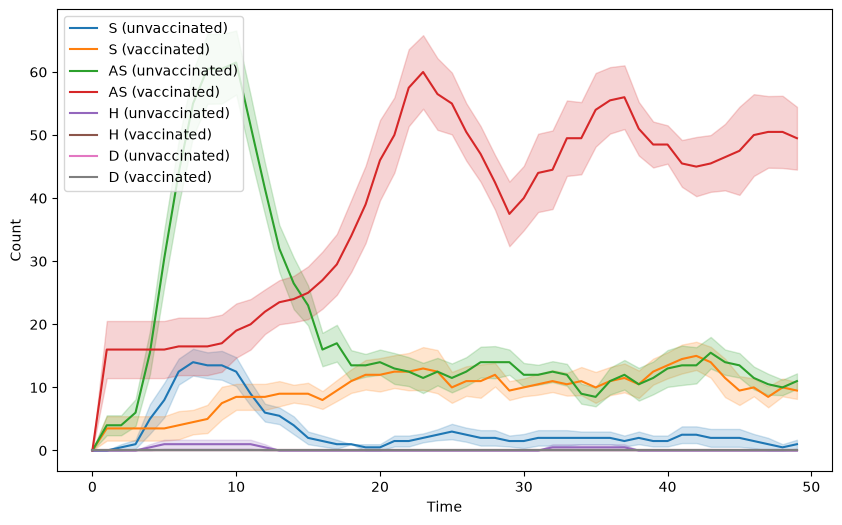

In [31]:
#
df_agg = aggregate_status(df_sum, group_cols=['t', 'vacc_status'])
df_sd_agg = aggregate_status_sd(df_sd, group_cols=['t', 'vacc_status'])
fig = plot_track_status(df_agg, df_sd_agg)

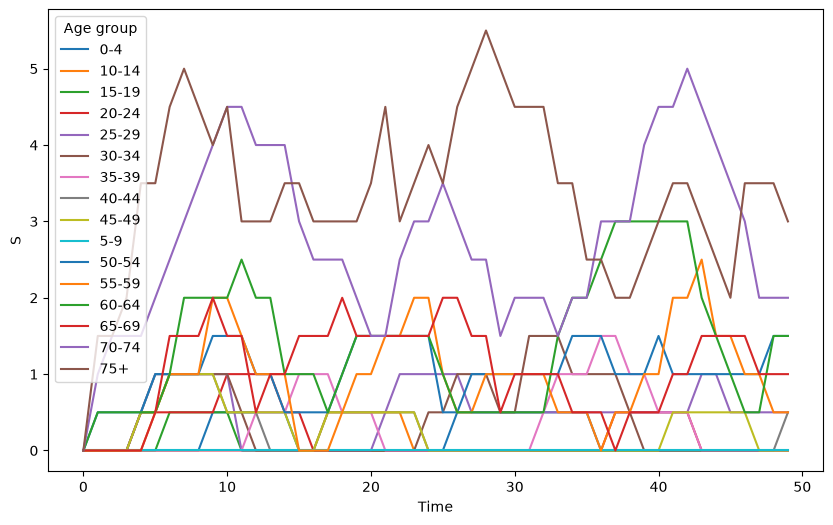

In [17]:
## AGE DYNAMICS

# aggregate over time instead of vacc status
df_sum, df_sd = load_status_data(sum_path='/home/bentevissel/vaccine-booster-optimisation/outputs/output_mean_strategy_1.csv', sd_path='/home/bentevissel/vaccine-booster-optimisation/outputs/output_std_strategy_1.csv')
df_age = aggregate_status(df_sum, group_cols=['t', 'ages'])

fig = plot_age_dynamics(df_age, status='S')
plt.show()

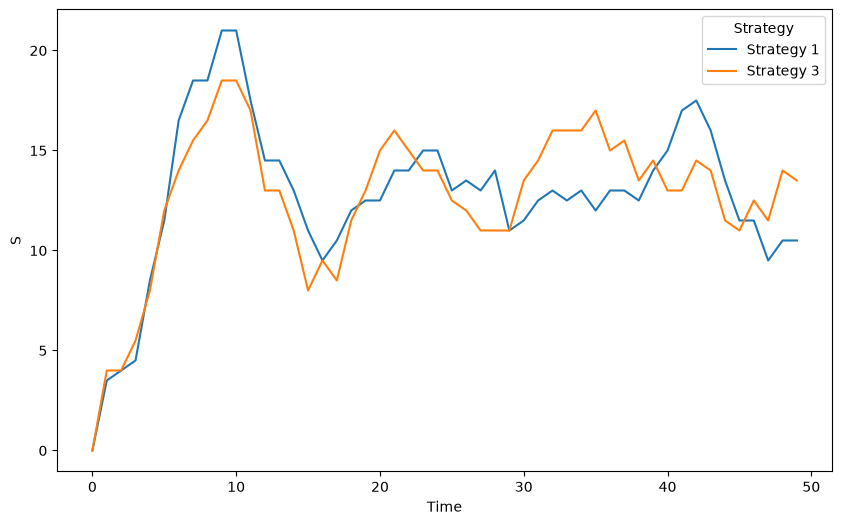

In [21]:
## COMPARE STRATEGIES
strategy_paths = {
    '1': '/home/bentevissel/vaccine-booster-optimisation/outputs/output_mean_strategy_1.csv',
    '3': '/home/bentevissel/vaccine-booster-optimisation/outputs/output_mean_strategy_3.csv',
}

strategy_data = {label: load_status_data(path)[0] for label, path in strategy_paths.items()}
# [0] grabs df_sum and discards df_sd, since load_status_data returns a tuple

strategy_agg = {label: aggregate_status(df, group_cols=['t']) for label, df in strategy_data.items()}

fig = plot_strategy_comparison(strategy_agg, status='S')
plt.show()


In [32]:
# strategy totals
totals = get_strategy_totals(strategy_agg, '1')
print(f"Strategy 1: Total deaths: {totals['total_deaths']:.0f}, Total hospitalisations: {totals['total_hospitalised']:.0f}")

Strategy 1: Total deaths: 0, Total hospitalisations: 11
